# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

In [7]:
url = 'https://raw.githubusercontent.com/Maryam-Shile/flyrank_ml_internship/refs/heads/main/data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [8]:
df['search_volume_log'] = np.log10(df['search_volume'] + 1)
df['opportunity_score'] = df['search_volume_log'] * df['competition']
df['opportunity_score'].describe()

,opportunity_score
count,27532.000000
mean,0.232301
std,0.497671
min,0.000000
25%,0.000000
50%,0.000000
75%,0.187451
max,4.377092


In [51]:
df['main_intent_x_content_type'] = df['main_intent'] + '_' + df['content_type']
info_data = df[df['main_intent_x_content_type'] == 'informational_keyword article'].copy()
info_data = info_data.drop(columns = ['main_intent_x_content_type'], axis = 1)

to_drop = []

for i in info_data.columns:
  if 'tier' in i:
    to_drop.append(i)
info_data = info_data.drop(columns = to_drop, axis = 1)


performance_columns = ['impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d','ctr', 'avg_position', 'engagement_rate',
       'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct']

performance_data = info_data[performance_columns]

performance_data_corr = performance_data.drop(columns = ['trend_direction'], axis = 1)


for i in performance_data.columns:
  if '30d' in i:
    performance_data = performance_data.drop(columns = [i], axis = 1)


performance_data = performance_data.drop(columns = ['sessions_90d', 'users_90d'], axis = 1)

info_data['avg_position'] = info_data['avg_position'].replace(0, pd.NA)

performance_columns = list(performance_data)
content_data_columns = ['content_id', 'client_id', 'cpc', 'content_type',
                        'main_intent', 'word_count',
                        'char_count', 'provider_used', 'model_used',
                        'content_age_days','days_since_last_update']

environment_columns = ['search_volume', 'competition', 'opportunity_score']

final_columns = content_data_columns + performance_columns + environment_columns

final_data = info_data[final_columns].copy()

higher = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate',
          'scroll_rate', 'ai_traffic_pct']
lower = ['avg_position']

for i in higher:
  name = i + '_rank'
  final_data[name] = final_data[i].rank(pct = True)

for j in lower:
  name = j + '_rank'
  final_data[name] = (-final_data[j]).rank(pct = True)

  perfomance_metrics = []
for i in final_data.columns:
  if 'rank' in i:
    perfomance_metrics.append(i)

final_data['performance_score'] = final_data[perfomance_metrics].sum(axis = 1) * 100 / len(perfomance_metrics)
final_data.head()


,content_id,client_id,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,content_age_days,...,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score
1,content_a1fb4e703a9e,client_4e07408562,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,445,...,0.466894,0.498458,0.801941,0.586588,0.453561,0.35110,0.634831,0.466894,0.316436,54.491081
2,content_9aa793d4d895,client_7f2253d7e2,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,141,...,0.466894,0.790210,0.801941,0.635627,0.514391,0.35110,0.804298,0.466894,0.112320,58.007439
4,content_d99b7a2d90ca,client_3fdba35f04,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,263,...,0.466894,0.985428,0.801941,0.870329,0.576793,0.35110,0.771244,0.466894,0.071551,64.889325
6,content_9a34b442b552,client_8722616204,0.00,keyword article,informational,3059.0,20810.0,google,gemini-3-flash-preview,90,...,0.466894,0.189503,0.130427,0.078667,0.205738,0.35110,0.190772,0.466894,0.754071,27.663007
8,content_5e6c160719bc,client_6208ef0f77,0.00,keyword article,informational,3807.0,24228.0,google,gemini-3-flash-preview,90,...,0.466894,0.877857,0.484460,0.916919,0.514391,0.88079,0.556063,0.466894,0.063441,68.517192


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

In [52]:
final_sorted = final_data.sort_values(by = 'performance_score', ascending = False)
bottom = final_sorted.tail(20).copy()
bottom

,content_id,client_id,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,content_age_days,...,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score
16139,content_ecd66bd563c9,client_e29c9c180c,0.00,keyword article,informational,1875.0,12285.0,NaN,gemini-2.5-flash,347,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
15795,content_d269b03793ea,client_e29c9c180c,0.00,keyword article,informational,1524.0,9881.0,NaN,gemini-2.5-flash,294,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
9236,content_2e2636503a92,client_9f14025af0,0.00,keyword article,informational,2479.0,16752.0,NaN,gpt-4o-mini,249,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
7677,content_8a0bd5419d80,client_e29c9c180c,0.00,keyword article,informational,1580.0,9729.0,NaN,gemini-2.5-flash,312,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
13078,content_1c296862b855,client_9f14025af0,0.00,keyword article,informational,2804.0,18962.0,NaN,gpt-4o-mini,250,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
653,content_ea9dd79ca225,client_f369cb89fc,0.00,keyword article,informational,2387.0,17961.0,google,gemini-3-flash-preview,126,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
9874,content_026291f3d24a,client_9f14025af0,0.00,keyword article,informational,2654.0,17977.0,NaN,gpt-4o-mini,250,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
441,content_c2fd66d7999d,client_e29c9c180c,0.00,keyword article,informational,1350.0,9135.0,NaN,gemini-2.5-flash,347,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
25692,content_ec722ec06f94,client_e29c9c180c,0.04,keyword article,informational,1305.0,8947.0,NaN,gemini-2.5-flash,320,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252
5984,content_9fa888cf46e4,client_9f14025af0,0.00,keyword article,informational,2821.0,18977.0,NaN,gpt-4o-mini,249,...,0.466894,0.189503,0.016205,0.078667,0.205738,0.3511,0.190772,0.466894,NaN,20.121252


In [54]:
bottom['trend_direction'].value_counts()

,count
trend_direction,
new,19
flat,1


In [55]:
down = final_sorted[final_sorted['trend_direction'] == 'down'].tail(20).copy()

In [56]:
loop = performance_columns + environment_columns
num_cols = list(down[loop].select_dtypes(include=['number']).columns)
cat_cols = list(down[loop].select_dtypes(exclude=['number']).columns)

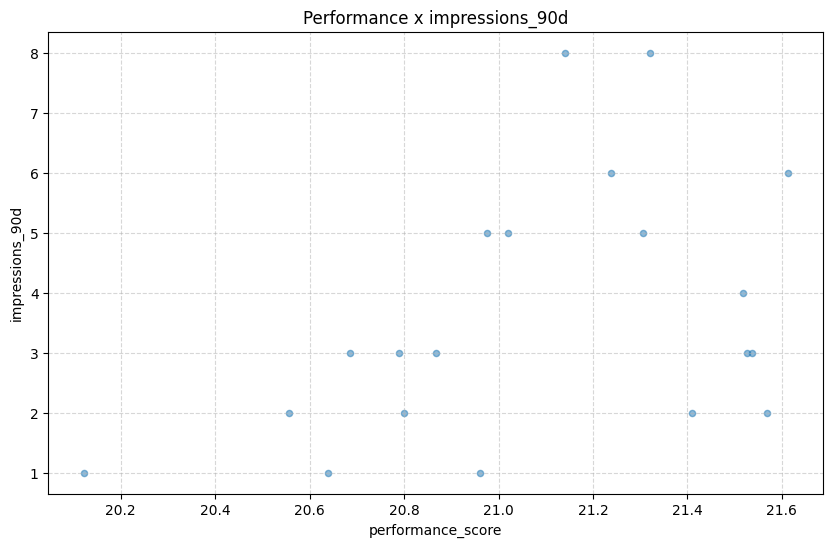

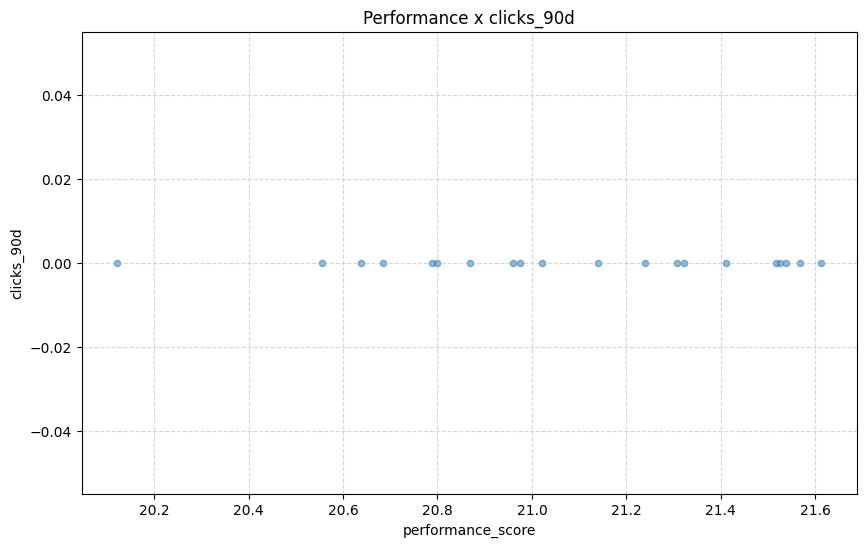

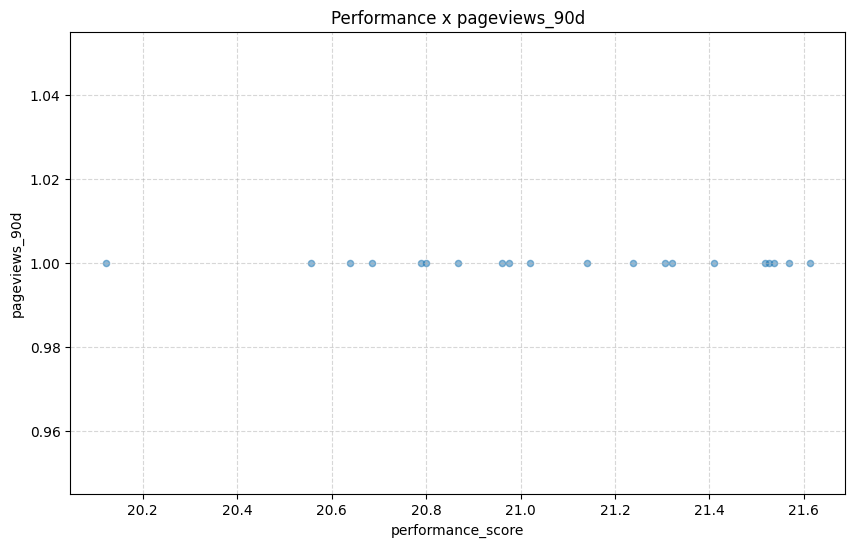

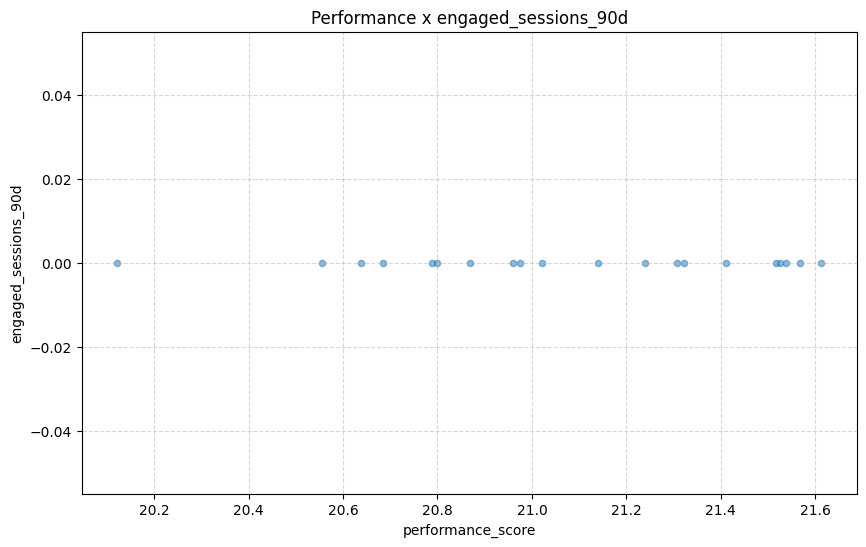

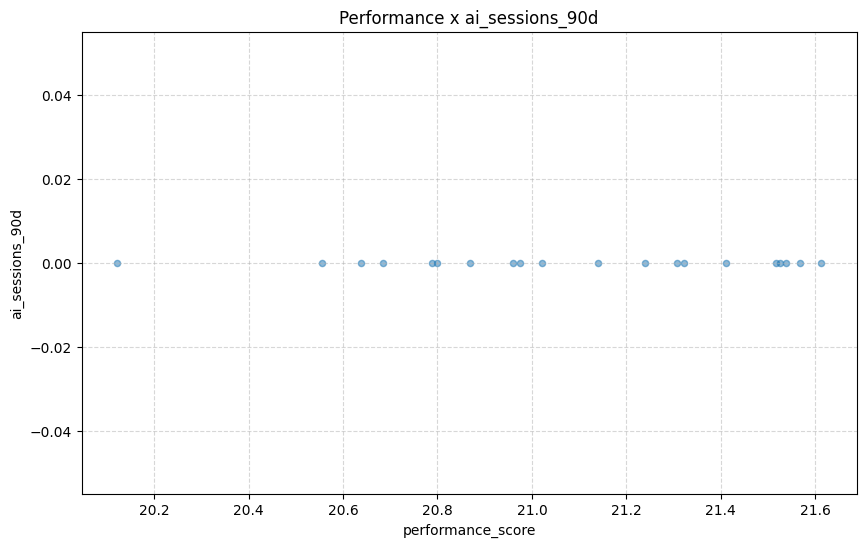

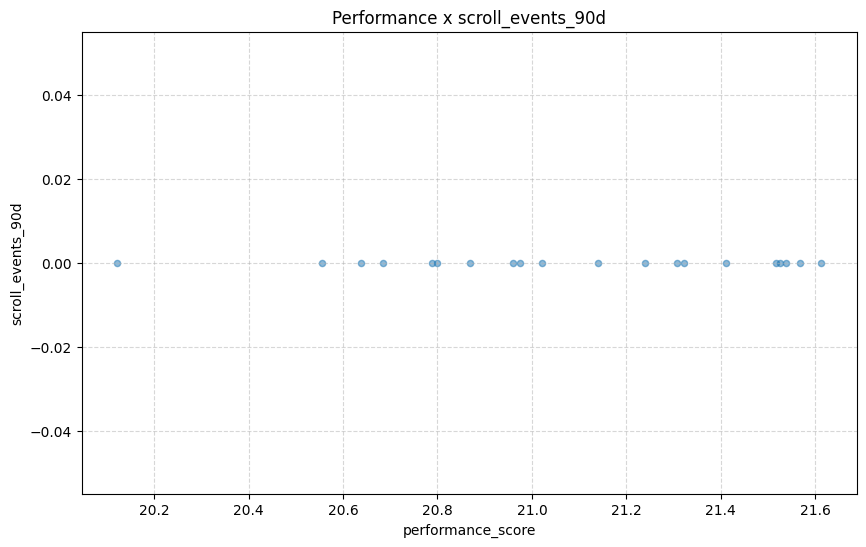

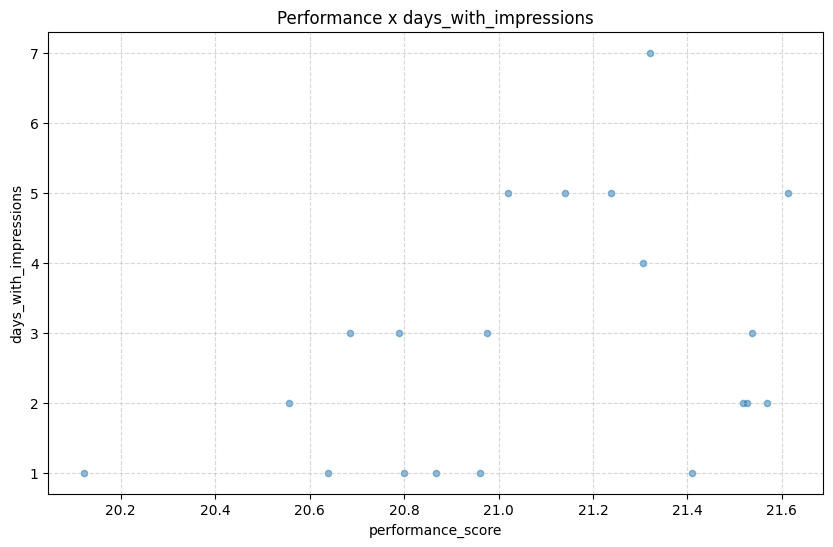

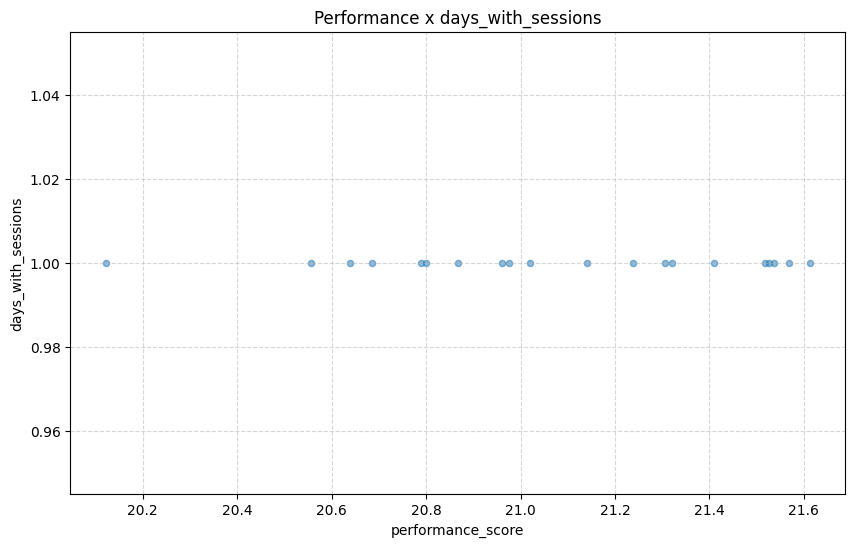

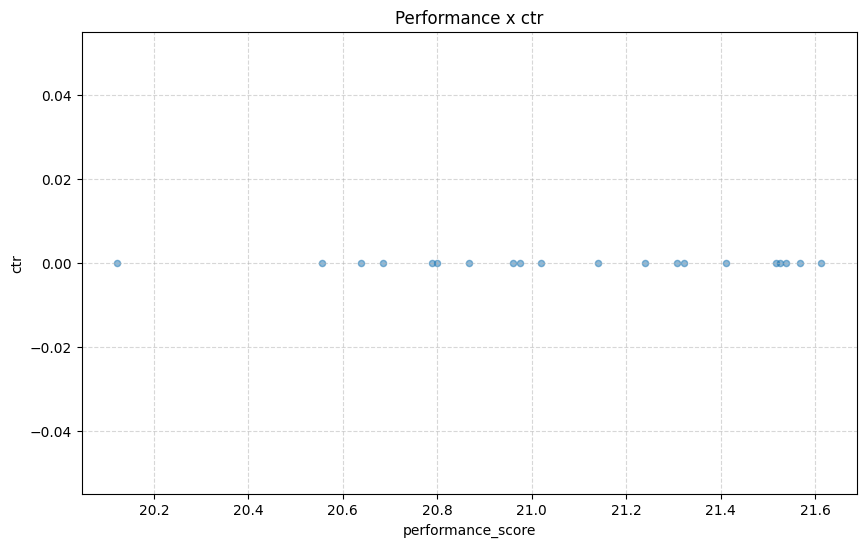

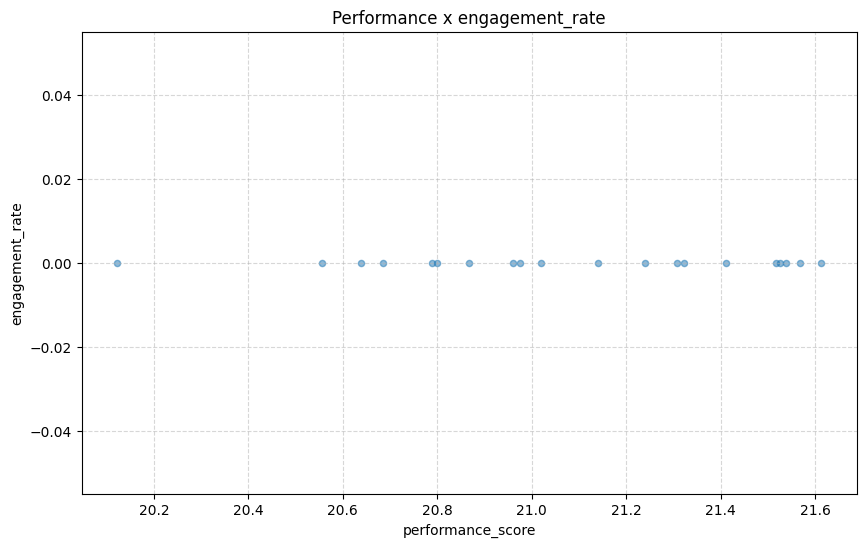

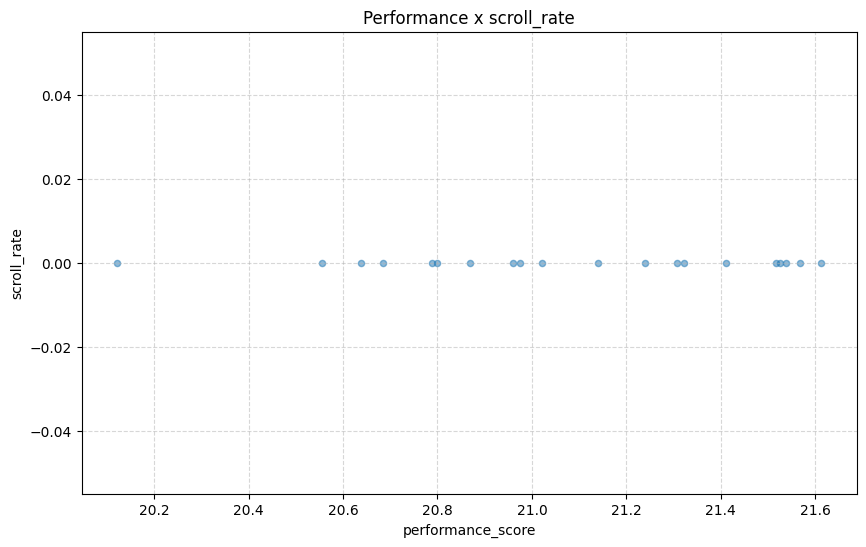

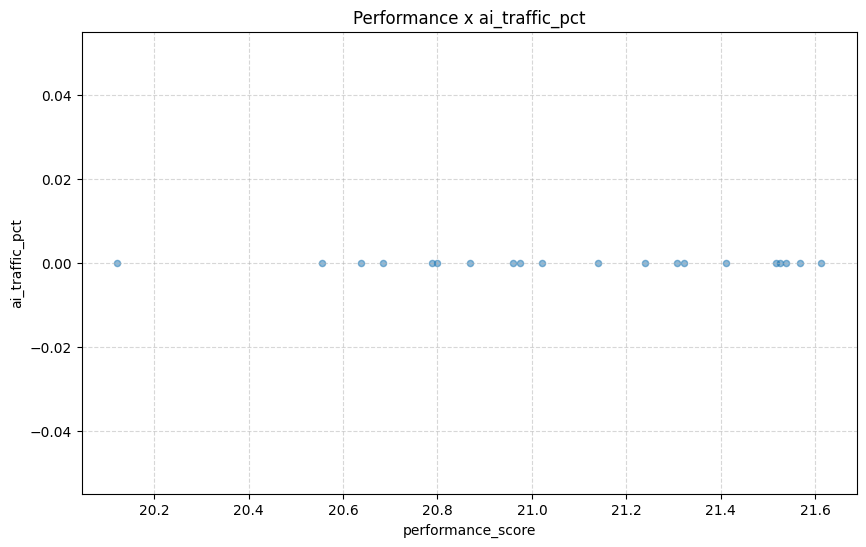

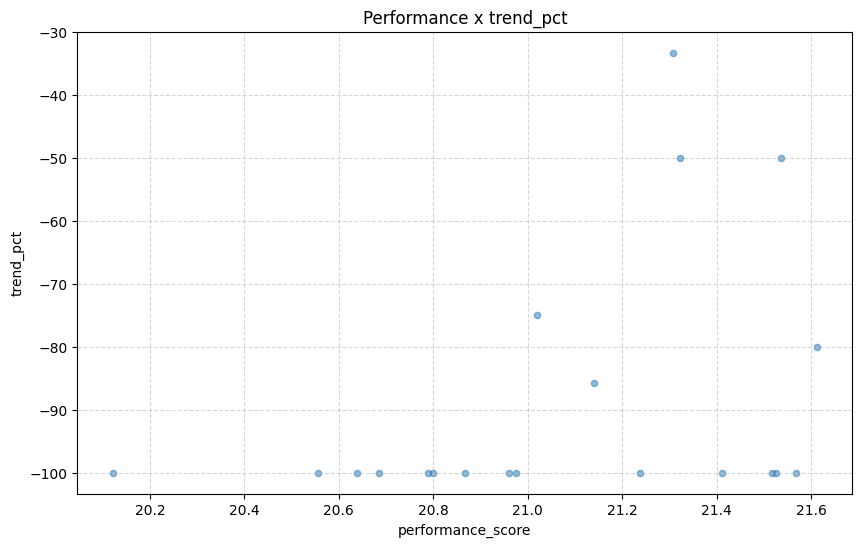

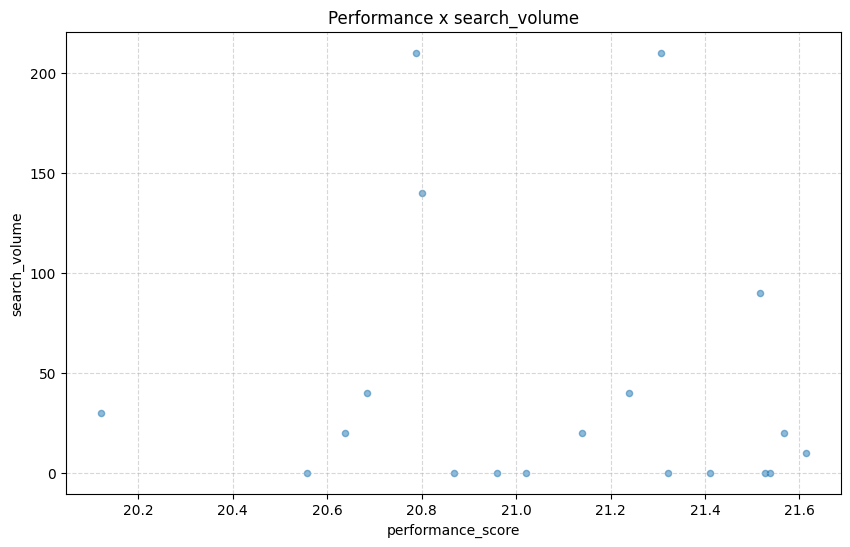

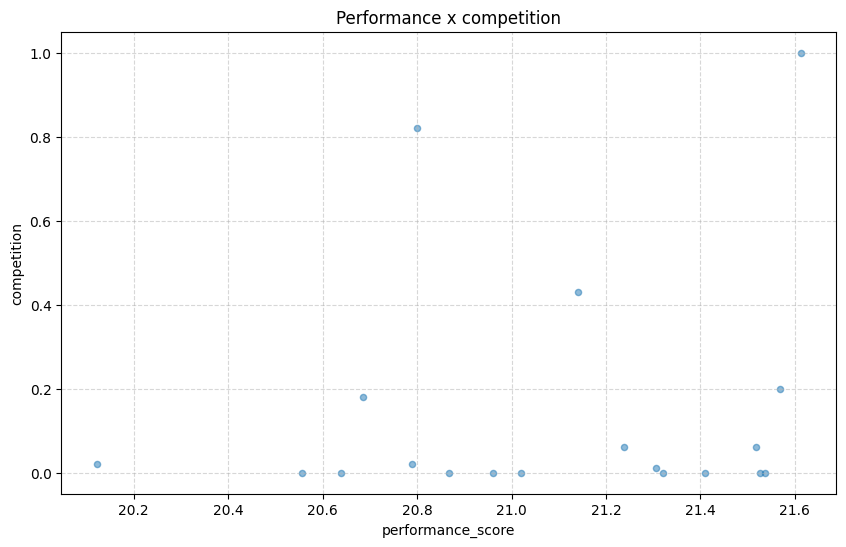

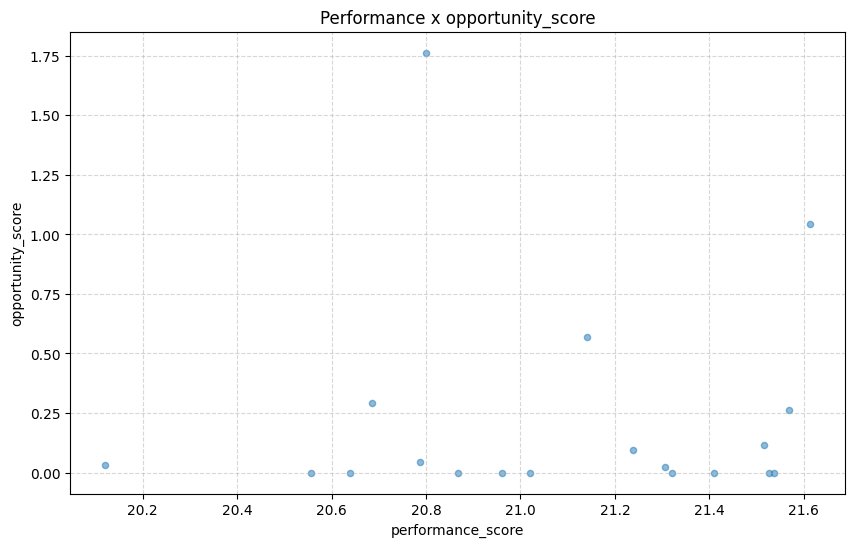

In [57]:
for i in num_cols:
  ax = down.plot(
    kind="scatter",
    x="performance_score",
    y=i,
    alpha=0.5,  # Makes overlapping points transparent so you can see density
    title= f"Performance x {i}",
    figsize=(10, 6),
)

  # Use log scale if high-volume outliers compress your chart
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()
  print ('')
  print('')

In [47]:
content_data_columns

['content_id',
 'client_id',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'content_age_days',
 'days_since_last_update']

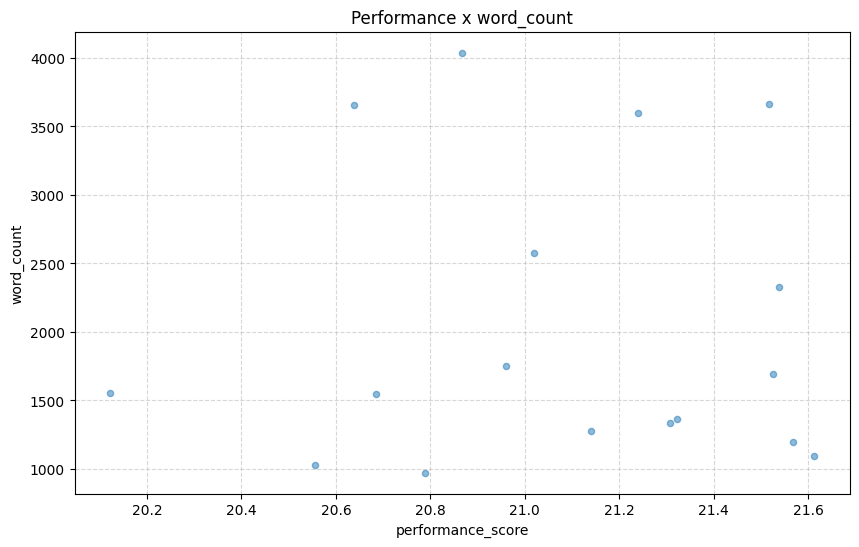

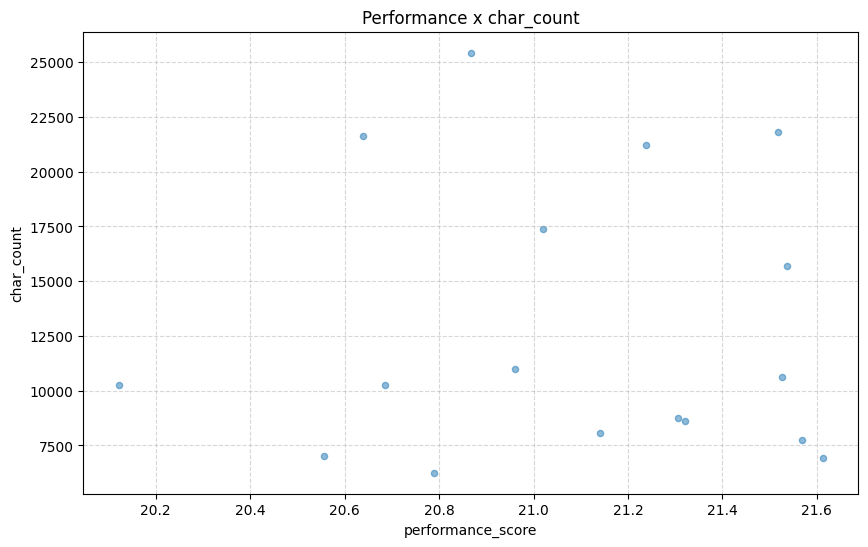

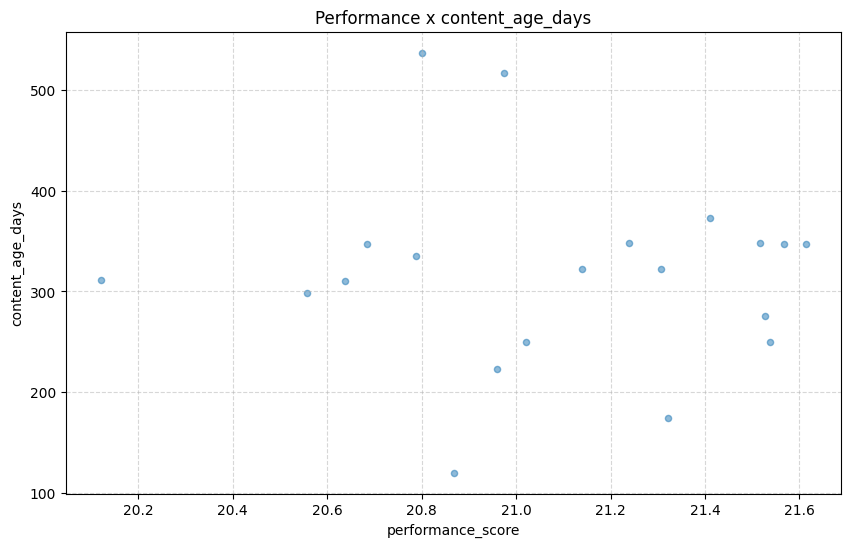

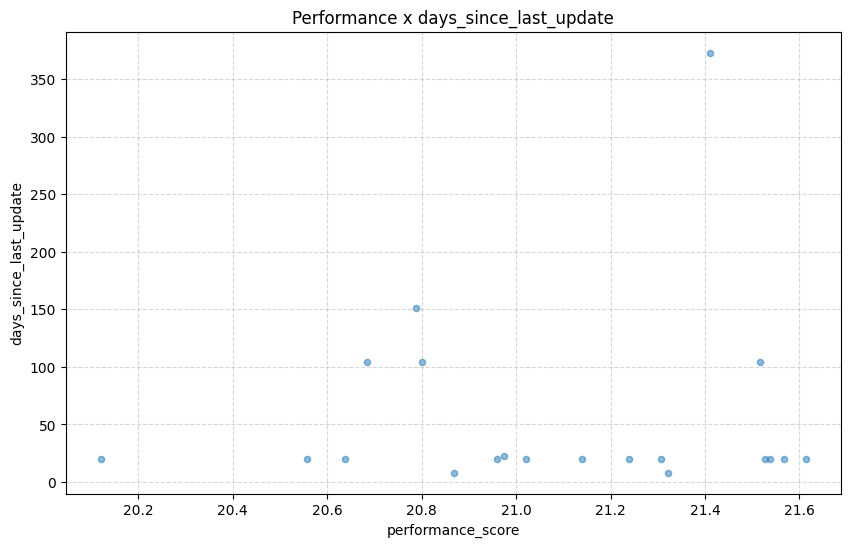

In [58]:
content_loop = ['word_count', 'char_count', 'content_age_days', 'days_since_last_update']
for i in content_loop:
  ax = down.plot(
    kind="scatter",
    x="performance_score",
    y=i,
    alpha=0.5,  # Makes overlapping points transparent so you can see density
    title= f"Performance x {i}",
    figsize=(10, 6),
)

  # Use log scale if high-volume outliers compress your chart
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()
  print ('')
  print('')

Inference for the reference group

Very low impressions with no ctr or engagement in 90 days, the opportunity score is also lower than the general mean of 0.232301. Average position is not available, although there is a bit of impression, which means that the discovery is not through a traditional search route.
Majority of them were recently updated (less than 50 days ago). It is also observed that the date of creation for most of the contents are over 300 days ago, which may mean that these contents may be archived because they no longer address a recent problem.

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

Features were carefully selected when calculating the performance score, to ensure that the features are unique and correlated features do not add a dead weight in inflating the score

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.